In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import statsmodels
import yfinance as yf

print("Setup works!")

Setup works!


In [5]:
tickers = ["SPY", "AAPL"]
start_date = "2022-01-01"
end_date = "2025-12-31"

In [6]:
import yfinance as yf

spy = yf.download(
    "SPY",
    start="2022-01-01",
    end="2026-01-01",
    auto_adjust=False
)

aapl = yf.download(
    "AAPL",
    start="2022-01-01",
    end="2026-01-01",
    auto_adjust=False
)

curl_cffi not available; falling back to requests without browser TLS impersonation. Yahoo Finance may rate-limit or block this client. Install curl_cffi (>=0.15) for the supported configuration.
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [7]:
spy.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2022-01-03,449.486450,477.709991,477.850006,473.850006,476.299988,72668200
2022-01-04,449.335876,477.549988,479.980011,475.579987,479.220001,71178700
2022-01-05,440.707703,468.380005,477.980011,468.279999,477.160004,104538900
2022-01-06,440.293671,467.940002,470.820007,465.429993,467.890015,86858900
2022-01-07,438.552979,466.089996,469.200012,464.649994,467.950012,85111600


In [8]:
aapl.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2022-01-03,177.786407,182.009995,182.880005,177.710007,177.830002,104487900
2022-01-04,175.530014,179.699997,182.940002,179.119995,182.630005,99310400
2022-01-05,170.860931,174.919998,180.169998,174.639999,179.610001,94537600
2022-01-06,168.008667,172.000000,175.300003,171.639999,172.699997,96904000
2022-01-07,168.174744,172.169998,174.139999,171.029999,172.889999,86709100


In [11]:
spy_price = spy["Adj Close"].dropna()
spy_price.head()

Ticker,SPY
Date,
2022-01-03,449.486450
2022-01-04,449.335876
2022-01-05,440.707703
2022-01-06,440.293671
2022-01-07,438.552979


In [12]:
spy_returns = np.log(spy_price) - np.log(spy_price.shift(1))
spy_returns = spy_returns.dropna()

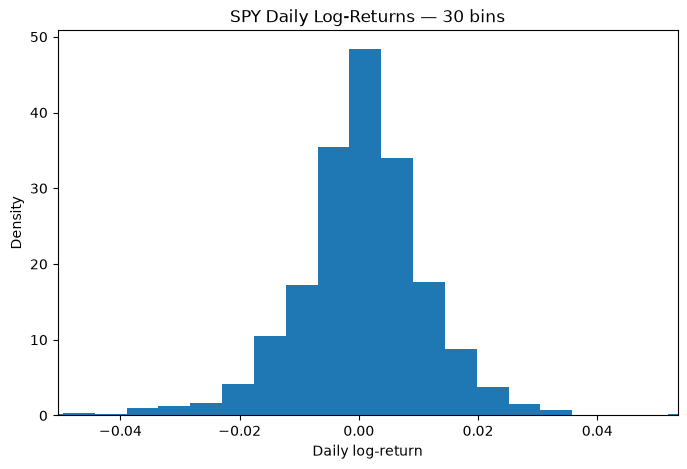

B = 30, total area = 1.000000


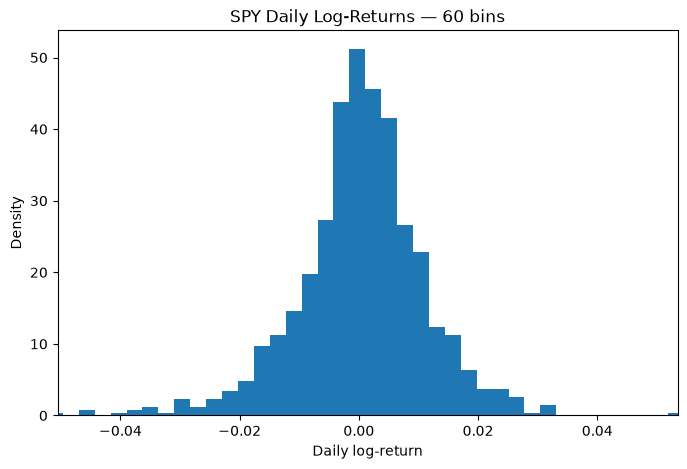

B = 60, total area = 1.000000


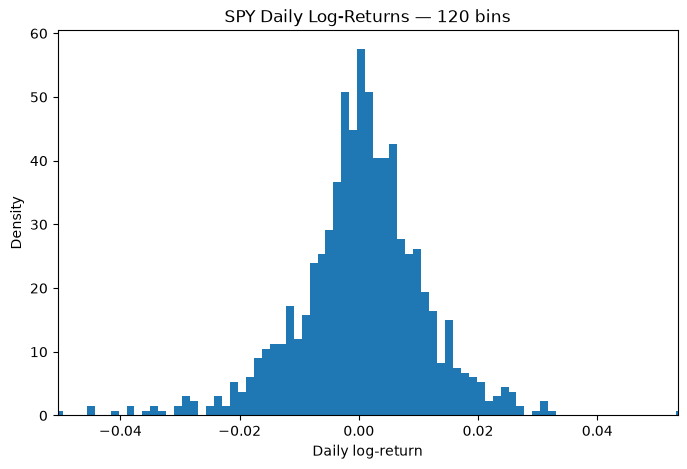

B = 120, total area = 1.000000


In [ ]:
for B in [30, 60, 120]:
    counts, bin_edges = np.histogram(
        spy_returns,
        bins=B,
        density=True
    )

    bin_widths = np.diff(bin_edges)

    plt.figure(figsize=(8, 5))
    plt.bar(
        bin_edges[:-1],
        counts,
        width=bin_widths,
        align="edge"
    )

    plt.xlim(q001, q999)
    plt.xlabel("Daily log-return")
    plt.ylabel("Density")
    plt.title(f"SPY Daily Log-Returns — {B} bins")
    plt.show()

    area = np.sum(counts * bin_widths)
    print(f"B = {B}, total area = {area:.6f}")

In [ ]:
aapl_price = aapl["Adj Close"].dropna()

In [ ]:
aapl_returns = np.log(aapl_price) - np.log(aapl_price.shift(1))
aapl_returns = aapl_returns.dropna()

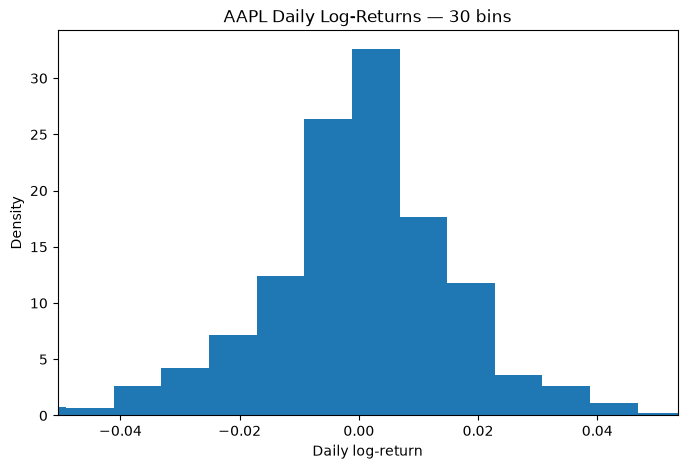

B = 30, total area = 1.000000


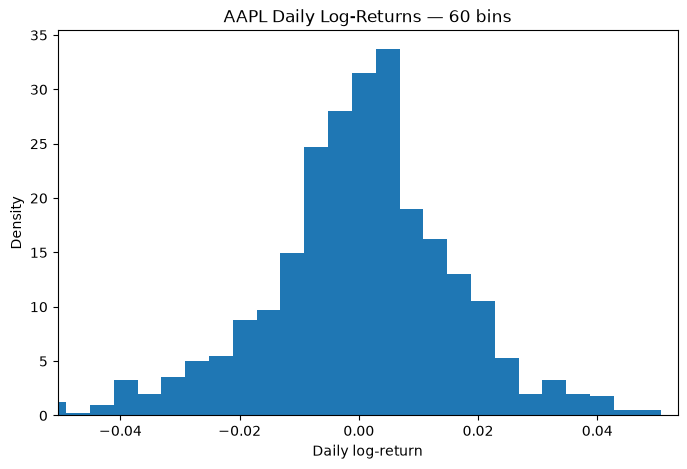

B = 60, total area = 1.000000


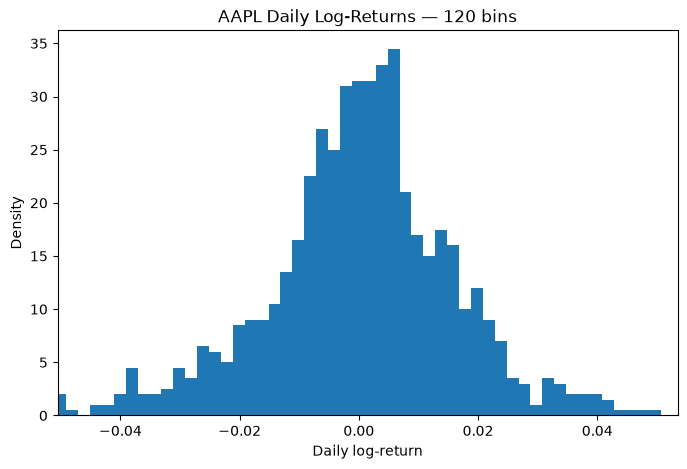

B = 120, total area = 1.000000


In [ ]:
for B in [30, 60, 120]:
    counts, bin_edges = np.histogram(
        aapl_returns,
        bins=B,
        density=True
    )

    bin_widths = np.diff(bin_edges)

    plt.figure(figsize=(8, 5))
    plt.bar(
        bin_edges[:-1],
        counts,
        width=bin_widths,
        align="edge"
    )

    plt.xlim(q001, q999)
    plt.xlabel("Daily log-return")
    plt.ylabel("Density")
    plt.title(f"AAPL Daily Log-Returns — {B} bins")
    plt.show()

    area = np.sum(counts * bin_widths)
    print(f"B = {B}, total area = {area:.6f}")

In [ ]:
#problem 1b

In [ ]:
import sys

print(sys.version)
print(sys.executable)

3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]
c:\Users\nickh\OneDrive\Documenten\Big data science for Finance\.venv\Scripts\python.exe


In [ ]:
import scipy

print(scipy.__version__)

1.18.1


In [14]:
print(type(spy_returns))
print(spy_returns.shape)

<class 'pandas.DataFrame'>
(1002, 1)


In [15]:
data = spy_returns.to_numpy().ravel()

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Number of observations
n = len(spy_returns)

# Scott's bandwidth factor
h_scott = n ** (-1 / 5)

# Standard deviation of the data
s = np.std(spy_returns, ddof=1)

# Actual reference bandwidth
h = h_scott * s

# x-values over which we evaluate the KDE
x = np.linspace(
    np.quantile(spy_returns, 0.001),
    np.quantile(spy_returns, 0.999),
    1000
)

# Gaussian KDE function
def gaussian_kde_manual(x, data, bandwidth):
    n = len(data)

    u = (x[:, None] - data[None, :]) / bandwidth

    kernel_values = (
        1 / np.sqrt(2 * np.pi)
        * np.exp(-0.5 * u**2)
    )

    return np.sum(kernel_values, axis=1) / (n * bandwidth)


# Plot the three bandwidths
plt.figure(figsize=(10, 6))

for c in [0.5, 1, 2]:
    bandwidth = c * h
    density = gaussian_kde_manual(
        x,
        spy_returns.to_numpy(),
        bandwidth
    )

    plt.plot(
        x,
        density,
        label=f"c = {c}"
    )

plt.xlabel("Daily log-return")
plt.ylabel("Density")
plt.title("SPY: Gaussian KDE for different bandwidths")
plt.legend()
plt.show()

ValueError: operands could not be broadcast together with shapes (1000,1) (1,1002,1) 

<Figure size 1000x600 with 0 Axes>